In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

from unifigs.figures import RatioPlot
from NNMFit.utilities import load_pickle


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load Bestfit Histograms (from step0_2_1_reco_space_graphs.ipynb)

In [21]:
step0_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/graphs"
PLOTS = []

In [22]:
# General plots

# Each entry defines one figure.
# 'scans'          : list of (scan_name, label) pairs — 1 for a single dataset, 2+ to overlay.
# 'show_counts'    : if True, append the bin integral to each legend label. Default False.
# 'plot_components': if True, overlay Astro/Conv/Muon components. Default False.
# 'dim_info ylim'  : optional (ymin, ymax) applied to the top panel for that column.
#                    Saved under: save_path / scans[0][0] / det_config.png
PLOTS += [
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Cascades With Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e2)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Tracks With Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 5e2)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades",
        "title": "HESE Tracks With Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 14),
            "bdt_product": np.linspace(0.122222211111, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True, "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "bdt_product": {"log_x": False, "log_y": True, "x_label": r"BDT product",            "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e2)},
        },
        "show_counts": True,
        "plot_components": True,
        "plot_data" : False,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
        "title": "HESE Cascades No Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3_NoSystematics", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e2)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
        "title": "HESE Tracks No Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3_NoSystematics", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (5e-4, 5e2)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades",
        "title": "HESE Tracks No Systematics",
        "scans": [("hese_spectrum_bestfit_13year_round3_NoSystematics", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 14),
            "bdt_product": np.linspace(0.122222211111, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True, "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "bdt_product": {"log_x": False, "log_y": True, "x_label": r"BDT product",            "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e2)},
        },
        "show_counts": True,
        "plot_components": True,
        "plot_data": False,
    },

    # # spice
    # {
    #     "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
    #     "title": "HESE Spice Cascades No Systematics",
    #     "scans": [("hese_seed_neha_NoSystematics", "MC")],
    #     "binning": {
    #         "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
    #         "reco_zenith": np.linspace(-1, 1, 11),
    #     },
    #     "dim_info": {
    #         "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
    #         "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e2)},
    #     },
    #     "show_counts": False,
    #     "plot_components": True,
    # },
    # {
    #     "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
    #     "title": "HESE Spice Tracks No Systematics",
    #     "scans": [("hese_seed_neha_NoSystematics", "MC")],
    #     "binning": {
    #         "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
    #         "reco_zenith": np.linspace(-1, 1, 11),
    #     },
    #     "dim_info": {
    #         "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
    #         "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 5e2)},
    #     },
    #     "show_counts": False,
    #     "plot_components": True,
    # },
    # {
    #     "det_config": "IC86_pass2_SnowStorm_FTP_HESE_DoubleCascades",
    #     "title": "HESE Spice Doubles No Systematics",
    #     "scans": [("hese_seed_neha_NoSystematics", "MC")],
    #     "binning": {
    #         "reco_energy": np.geomspace(10**4.778, 10**7.1, 14),
    #         "reco_length": np.geomspace(1e1, 1e3, 11),
    #     },
    #     "dim_info": {
    #         "reco_energy": {"log_x": True, "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
    #         "reco_length": {"log_x": True, "log_y": True, "x_label": r"$L_{\tau}$ [m]",            "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e1)},
    #     },
    #     "show_counts": False,
    #     "plot_components": True,
    # },

    # # ftp sim and data
    # {
    #     "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Cascades",
    #     "title": "HESE Cascades Best fit Neha with flavor",
    #     "scans": [("FTP_data_sim_seed_neha_WithFlavor_NoSystematics", "MC")],
    #     "binning": {
    #         "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
    #         "reco_zenith": np.linspace(-1, 1, 11),
    #     },
    #     "dim_info": {
    #         "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
    #         "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e2)},
    #     },
    #     "show_counts": False,
    #     "plot_components": True,
    # },
    # {
    #     "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Tracks",
    #     "title": "HESE Tracks Best fit Neha, with flavor",
    #     "scans": [("FTP_data_sim_seed_neha_WithFlavor_NoSystematics", "MC")],
    #     "binning": {
    #         "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
    #         "reco_zenith": np.linspace(-1, 1, 11),
    #     },
    #     "dim_info": {
    #         "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
    #         "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e2)},
    #     },
    #     "show_counts": False,
    #     "plot_components": True,
    # }
]

In [46]:
# combined bdt variables, without systematics
PLOTS += [
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined No Systematics",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-3, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined BDT Scores No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_bdt1_bdt2", "MC")],
        "binning": {
            "bdt_scores1": np.linspace(0.0, 1, 11),
            "bdt_scores2": np.linspace(0.0, 1, 11),
        },
        "dim_info": {
            "bdt_scores1": {"log_x": False, "log_y": True, "x_label": "BDT Score 1", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "bdt_scores2": {"log_x": False, "log_y": True, "x_label": "BDT Score 2", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined energy length analysis No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_energy_length_analysis", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 14),
            "reco_length": np.geomspace(1e1, 1e3, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True, "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_length": {"log_x": True, "log_y": True, "x_label": r"$L_{\tau}$ [m]",            "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined Taupede Length vs Asymmetry No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_len_easym", "MC")],
        "binning": {
            "Taupede_Distance": np.geomspace(10**0.1360, 10**3.0133, 11),
            "Taupede_Asymmetry": np.linspace(-1.001, 1.001, 11),
        },
        "dim_info": {
            "Taupede_Distance":  {"log_x": True,  "log_y": True, "x_label": "Taupede Length",    "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "Taupede_Asymmetry": {"log_x": False, "log_y": True, "x_label": "Taupede Asymmetry", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Taupede Particle Energies No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_e1_e2", "MC")],
        "binning": {
            "Taupede1_Particles_energy": np.geomspace(10**1.9875, 10**10.3972, 11),
            "Taupede2_Particles_energy": np.geomspace(10**0.5207, 10**8.0231, 11),
        },
        "dim_info": {
            "Taupede1_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 1", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e3)},
            "Taupede2_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 2", "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "MonopodFit Energy vs Zenith No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_mono_energy_zenith", "MC")],
        "binning": {
            "MonopodFit_iMIGRAD_PPB0_energy":  np.geomspace(10**4.4758, 10**8.2502, 11),
            "cscdSBU_MonopodFit4_noDC_zenith": np.linspace(0.0317, 3.1400, 11),
        },
        "dim_info": {
            "MonopodFit_iMIGRAD_PPB0_energy":  {"log_x": True,  "log_y": True, "x_label": "MonopodFit Energy", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "cscdSBU_MonopodFit4_noDC_zenith": {"log_x": False, "log_y": True, "x_label": "Monopod Zenith",    "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "MonopodFit Delay vs Q Max DOMs No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_mono_delay_qmax", "MC")],
        "binning": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": np.linspace(-15011.9669, 1120.3790, 11),
            "CVStatistics_q_max_doms":            np.linspace(-712.6985, 22417.2985, 11),
        },
        "dim_info": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": {"log_x": False, "log_y": True, "x_label": "Delay Ice",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "CVStatistics_q_max_doms":            {"log_x": False, "log_y": True, "x_label": "Q Max DOMs", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Vertex Reco Dist vs Qtot HLC No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_vtxdist_qtot", "MC")],
        "binning": {
            "cscdSBU_VertexRecoDist_CscdLLh": np.linspace(-18.1670, 462.2055, 11),
            "cscdSBU_Qtot_HLC_log":           np.linspace(3.7310, 5.5967, 11),
        },
        "dim_info": {
            "cscdSBU_VertexRecoDist_CscdLLh": {"log_x": False, "log_y": True, "x_label": "Vertex Reco Dist Cscd", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "cscdSBU_Qtot_HLC_log":           {"log_x": False, "log_y": True, "x_label": "log10(Qtot HLC)",       "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauMono rlogl vs Econfinement No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_taumono_econf", "MC")],
        "binning": {
            "TauMonoDiff_rlogl": np.linspace(-8.8396, 0.4251, 11),
            "econfinement":      np.linspace(-0.001, 1.001, 11),
        },
        "dim_info": {
            "TauMonoDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono rlogl", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "econfinement":      {"log_x": False, "log_y": True, "x_label": "Econfinement",   "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauSPE vs TauMono Milli rlogl No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_tauspe_taumilli", "MC")],
        "binning": {
            "TauSPEMilliDiff_rlogl":  np.linspace(-7.0223, 1.1643, 11),
            "TauMonoMilliDiff_rlogl": np.linspace(-4.5702, 0.2189, 11),
        },
        "dim_info": {
            "TauSPEMilliDiff_rlogl":  {"log_x": False, "log_y": True, "x_label": "Tau-SPE Milli rlogl",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "TauMonoMilliDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono Milli rlogl", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "EventGenerator Length vs E Ratio No syst",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_NoSystematics_evtgen_recoeratio", "MC")],
        "binning": {
            "EventGeneratorDC_Thijs_length":   np.linspace(-446.7254, 838.6997, 11),
            "RecoERatio_EventGeneratorDC_Max": np.linspace(-1.1000, 1.0984, 11),
        },
        "dim_info": {
            "EventGeneratorDC_Thijs_length":   {"log_x": False, "log_y": True, "x_label": "EventGen Length", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "RecoERatio_EventGeneratorDC_Max": {"log_x": False, "log_y": True, "x_label": "EvtGen E Ratio",  "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
]


In [9]:
# combined bdt variables, with systematics
PLOTS += [
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 24),
            "reco_zenith": np.linspace(-1, 1, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True,  "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]",          "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_zenith": {"log_x": False, "log_y": True, "x_label": r"$\cos(\theta_{\mathrm{reco}})$", "sum_axes": 0, "flip": True,  "ylim": (1e-2, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined BDT Scores",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_bdt1_bdt2", "MC")],
        "binning": {
            "bdt_scores1": np.linspace(0.0, 1, 11),
            "bdt_scores2": np.linspace(0.0, 1, 11),
        },
        "dim_info": {
            "bdt_scores1": {"log_x": False, "log_y": True, "x_label": "BDT Score 1", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "bdt_scores2": {"log_x": False, "log_y": True, "x_label": "BDT Score 2", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined BDT Scores",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_energy_length_analysis", "MC")],
        "binning": {
            "reco_energy": np.geomspace(10**4.778, 10**7.1, 14),
            "reco_length": np.geomspace(1e1, 1e3, 11),
        },
        "dim_info": {
            "reco_energy": {"log_x": True, "log_y": True, "x_label": r"$E_{\mathrm{reco}}$ [GeV]", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "reco_length": {"log_x": True, "log_y": True, "x_label": r"$L_{\tau}$ [m]",            "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e2)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined Taupede Length vs Asymmetry",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_len_easym", "MC")],
        "binning": {
            "Taupede_Distance": np.geomspace(10**0.1360, 10**3.0133, 11),
            "Taupede_Asymmetry": np.linspace(-1.001, 1.001, 11),
        },
        "dim_info": {
            "Taupede_Distance":  {"log_x": True,  "log_y": True, "x_label": "Taupede Length",    "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "Taupede_Asymmetry": {"log_x": False, "log_y": True, "x_label": "Taupede Asymmetry", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "HESE Combined Taupede Length vs Asymmetry",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_len_easym_zheyang", "MC")],
        "binning": {
            "Taupede_Distance": np.linspace(0, 100, 21),
            "Taupede_Asymmetry": np.linspace(-1.001, 1.001, 21),
        },
        "dim_info": {
            "Taupede_Distance":  {"log_x": False,  "log_y": True, "x_label": "Taupede Length",    "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "Taupede_Asymmetry": {"log_x": False, "log_y": True, "x_label": "Taupede Asymmetry", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },

    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Taupede Particle Energies",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_e1_e2", "MC")],
        "binning": {
            "Taupede1_Particles_energy": np.geomspace(10**1.9875, 10**10.3972, 11),
            "Taupede2_Particles_energy": np.geomspace(10**0.5207, 10**8.0231, 11),
        },
        "dim_info": {
            "Taupede1_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 1", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e3)},
            "Taupede2_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 2", "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Taupede Particle Energies",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_e1_e2_zoom", "MC")],
        "binning": {
            "Taupede1_Particles_energy": np.geomspace(10**2, 10**7, 11),
            "Taupede2_Particles_energy": np.geomspace(10**2, 10**7, 11),
        },
        "dim_info": {
            "Taupede1_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 1", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e3)},
            "Taupede2_Particles_energy": {"log_x": True, "log_y": True, "x_label": "Taupede Energy 2", "sum_axes": 0, "flip": False, "ylim": (1e-2, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "MonopodFit Energy vs Zenith",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_mono_energy_zenith", "MC")],
        "binning": {
            "MonopodFit_iMIGRAD_PPB0_energy":  np.geomspace(10**4.4758, 10**8.2502, 11),
            "cscdSBU_MonopodFit4_noDC_zenith": np.linspace(0.0317, 3.1400, 11),
        },
        "dim_info": {
            "MonopodFit_iMIGRAD_PPB0_energy":  {"log_x": True,  "log_y": True, "x_label": "MonopodFit Energy", "sum_axes": 1, "flip": False, "ylim": (1e-2, 1e2)},
            "cscdSBU_MonopodFit4_noDC_zenith": {"log_x": False, "log_y": True, "x_label": "Monopod Zenith",    "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "MonopodFit Delay vs Q Max DOMs",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_mono_delay_qmax", "MC")],
        "binning": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": np.linspace(-15011.9669, 1120.3790, 11),
            "CVStatistics_q_max_doms":            np.linspace(-712.6985, 22417.2985, 11),
        },
        "dim_info": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": {"log_x": False, "log_y": True, "x_label": "Delay Ice",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "CVStatistics_q_max_doms":            {"log_x": False, "log_y": True, "x_label": "Q Max DOMs", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "MonopodFit Delay vs Q Max DOMs",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_mono_delay_qmax_zoom", "MC")],
        "binning": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": np.linspace(-2000, 1000, 11),
            "CVStatistics_q_max_doms":            np.linspace(0, 10000, 11),
        },
        "dim_info": {
            "MonopodFit_iMIGRAD_PPB0_Delay_ice": {"log_x": False, "log_y": True, "x_label": "Delay Ice",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "CVStatistics_q_max_doms":            {"log_x": False, "log_y": True, "x_label": "Q Max DOMs", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Vertex Reco Dist vs Qtot HLC",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_vtxdist_qtot", "MC")],
        "binning": {
            "cscdSBU_VertexRecoDist_CscdLLh": np.linspace(-18.1670, 462.2055, 11),
            "cscdSBU_Qtot_HLC_log":           np.linspace(3.7310, 5.5967, 11),
        },
        "dim_info": {
            "cscdSBU_VertexRecoDist_CscdLLh": {"log_x": False, "log_y": True, "x_label": "Vertex Reco Dist Cscd", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "cscdSBU_Qtot_HLC_log":           {"log_x": False, "log_y": True, "x_label": "log10(Qtot HLC)",       "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "Vertex Reco Dist vs Qtot HLC",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_vtxdist_qtot_zoom", "MC")],
        "binning": {
            "cscdSBU_VertexRecoDist_CscdLLh": np.linspace(0, 150, 11),
            "cscdSBU_Qtot_HLC_log":           np.linspace(3.7310, 5.5967, 11),
        },
        "dim_info": {
            "cscdSBU_VertexRecoDist_CscdLLh": {"log_x": False, "log_y": True, "x_label": "Vertex Reco Dist Cscd", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "cscdSBU_Qtot_HLC_log":           {"log_x": False, "log_y": True, "x_label": "log10(Qtot HLC)",       "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauMono rlogl vs Econfinement",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_taumono_econf", "MC")],
        "binning": {
            "TauMonoDiff_rlogl": np.linspace(-8.8396, 0.4251, 11),
            "econfinement":      np.linspace(-0.001, 1.001, 11),
        },
        "dim_info": {
            "TauMonoDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono rlogl", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "econfinement":      {"log_x": False, "log_y": True, "x_label": "Econfinement",   "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauMono rlogl vs Econfinement",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_taumono_econf_zoom", "MC")],
        "binning": {
            "TauMonoDiff_rlogl": np.linspace(-2.5, 0.2, 11),
            "econfinement":      np.linspace(0.75, 1.001, 11),
        },
        "dim_info": {
            "TauMonoDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono rlogl", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "econfinement":      {"log_x": False, "log_y": True, "x_label": "Econfinement",   "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauMono rlogl vs Econfinement",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_taumono_econf_zheyang", "MC")],
        "binning": {
            "TauMonoDiff_rlogl": np.linspace(-0.5, 0.1, 21),
            "econfinement":      np.linspace(0.95, 1.001, 21),
        },
        "dim_info": {
            "TauMonoDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono rlogl", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "econfinement":      {"log_x": False, "log_y": True, "x_label": "Econfinement",   "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauSPE vs TauMono Milli rlogl",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_tauspe_taumilli", "MC")],
        "binning": {
            "TauSPEMilliDiff_rlogl":  np.linspace(-7.0223, 1.1643, 11),
            "TauMonoMilliDiff_rlogl": np.linspace(-4.5702, 0.2189, 11),
        },
        "dim_info": {
            "TauSPEMilliDiff_rlogl":  {"log_x": False, "log_y": True, "x_label": "Tau-SPE Milli rlogl",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "TauMonoMilliDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono Milli rlogl", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauSPE vs TauMono Milli rlogl",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_tauspe_taumilli_zoom", "MC")],
        "binning": {
            "TauSPEMilliDiff_rlogl":  np.linspace(-2, 1, 11),
            "TauMonoMilliDiff_rlogl": np.linspace(-1.5, 0.2, 11),
        },
        "dim_info": {
            "TauSPEMilliDiff_rlogl":  {"log_x": False, "log_y": True, "x_label": "Tau-SPE Milli rlogl",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "TauMonoMilliDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono Milli rlogl", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "TauSPE vs TauMono Milli rlogl",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_tauspe_taumilli_zheyang", "MC")],
        "binning": {
            "TauSPEMilliDiff_rlogl":  np.linspace(-2, 1, 21),
            "TauMonoMilliDiff_rlogl": np.linspace(-1.0, 0.2, 21),
        },
        "dim_info": {
            "TauSPEMilliDiff_rlogl":  {"log_x": False, "log_y": True, "x_label": "Tau-SPE Milli rlogl",  "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "TauMonoMilliDiff_rlogl": {"log_x": False, "log_y": True, "x_label": "Tau-Mono Milli rlogl", "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "EventGenerator Length vs E Ratio",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_evtgen_recoeratio", "MC")],
        "binning": {
            "EventGeneratorDC_Thijs_length":   np.linspace(-446.7254, 838.6997, 11),
            "RecoERatio_EventGeneratorDC_Max": np.linspace(-1.1000, 1.0984, 11),
        },
        "dim_info": {
            "EventGeneratorDC_Thijs_length":   {"log_x": False, "log_y": True, "x_label": "EventGen Length", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "RecoERatio_EventGeneratorDC_Max": {"log_x": False, "log_y": True, "x_label": "EvtGen E Ratio",  "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "EventGenerator Length vs E Ratio",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_evtgen_recoeratio_zoom", "MC")],
        "binning": {
            "EventGeneratorDC_Thijs_length":   np.geomspace(1e0, 1e3, 11),
            "RecoERatio_EventGeneratorDC_Max": np.linspace(-1.1000, 1.0984, 11),
        },
        "dim_info": {
            "EventGeneratorDC_Thijs_length":   {"log_x": True, "log_y": True, "x_label": "EventGen Length", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "RecoERatio_EventGeneratorDC_Max": {"log_x": False, "log_y": True, "x_label": "EvtGen E Ratio",  "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
    {
        "det_config": "IC86_pass2_SnowStorm_FTP_HESE_Combined",
        "title": "EventGenerator Length vs E Ratio",
        "scans": [("hese_combined_spectrum_bestfit_13year_round3_evtgen_recoeratio_zheyang", "MC")],
        "binning": {
            "EventGeneratorDC_Thijs_length":   np.linspace(0, 100, 21),
            "RecoERatio_EventGeneratorDC_Max": np.linspace(-1.0010, 1.0010, 21),
        },
        "dim_info": {
            "EventGeneratorDC_Thijs_length":   {"log_x": False, "log_y": True, "x_label": "EventGen Length", "sum_axes": 1, "flip": False, "ylim": (1e-1, 1e3)},
            "RecoERatio_EventGeneratorDC_Max": {"log_x": False, "log_y": True, "x_label": "EvtGen E Ratio",  "sum_axes": 0, "flip": False, "ylim": (1e-1, 1e3)},
        },
        "show_counts": False,
        "plot_components": True,
    },
]


In [23]:
COMPONENTS = ["Astro", "Conv", "Muon"]

# collect unique scan names in order they first appear
scan_names = list(dict.fromkeys(
    scan_name
    for plot in PLOTS
    for scan_name, _ in plot["scans"]
))

histogram_collection = {}
for scan_name in scan_names:
    print(scan_name)
    histogram_collection[scan_name] = {}
    data_hist_path = glob.glob(os.path.join(step0_path, scan_name, "Data_Histogram.pickle"))
    if len(data_hist_path) != 1:
        raise ValueError(f"Expected exactly one Data_Histogram.pickle for {scan_name}, found {len(data_hist_path)}")
    histogram_collection[scan_name]["data"] = load_pickle(data_hist_path[0])

    mc_hist_path = glob.glob(os.path.join(step0_path, scan_name, "MC_Histogram.pickle"))
    if len(mc_hist_path) < 1:
        raise ValueError(f"Expected at least one MC_Histogram.pickle for {scan_name}, found {len(mc_hist_path)}")
    histogram_collection[scan_name]["mc"] = load_pickle(mc_hist_path[0])

    for component in COMPONENTS:
        comp_paths = glob.glob(os.path.join(step0_path, scan_name, f"MC_Histogram_{component}.pickle"))
        if comp_paths:
            histogram_collection[scan_name][component] = load_pickle(comp_paths[0])


hese_spectrum_bestfit_13year_round3
hese_spectrum_bestfit_13year_round3_NoSystematics


### Plotting Functions

In [24]:
def get_histogram_projection(
    histogram, det_config, binning, dims, projected_dimension, flip=False
):
    """
    binning : dict of {var_name: edges_array} for this det_config
    dims    : dict of {var_name: dim_info_dict} for this det_config
    """
    reshape_shape = tuple(binning[dim].shape[0] - 1 for dim in binning)
    sum_axis = dims[projected_dimension]["sum_axes"]
    h = np.sum(np.reshape(histogram, reshape_shape), axis=sum_axis)
    if flip:
        h = np.flip(h, axis=0)
    return h


def plot_histogram(
    ax, histogram_dict, det_config, plot_dimension, binning, dims,
    draw_style="stairs", label="Label", color="black", **kwargs,
):
    histogram = get_histogram_projection(
        histogram_dict["histograms"][det_config], det_config, binning, dims,
        projected_dimension=plot_dimension,
        flip=dims[plot_dimension]["flip"],
    )
    if "fluctuations" not in histogram_dict or histogram_dict["fluctuations"] is None:
        fluctuations = np.sqrt(histogram)
    else:
        fluctuations = get_histogram_projection(
            np.sqrt(histogram_dict["fluctuations"][det_config]), det_config, binning, dims,
            projected_dimension=plot_dimension,
            flip=dims[plot_dimension]["flip"],
        )
    if draw_style == "stairs":
        ax.stairs(histogram, binning[plot_dimension], label=label, color=color, **kwargs)
    elif draw_style == "errors":
        bin_centers = np.diff(binning[plot_dimension]) / 2 + binning[plot_dimension][:-1]
        ax.errorbar(bin_centers, histogram, yerr=fluctuations,
                    fmt=".", label=label, color=color, **kwargs)


def calc_ratio_err(numerator, denominator, err_numerator, err_denominator):
    ratio = numerator / denominator
    ratio_err = ratio * np.sqrt(
        (err_numerator / numerator)**2 + (err_denominator / denominator)**2
    )
    return ratio, ratio_err


def plot_ratio(
    ax, mc_dict, data_dict, det_config, plot_dimension, binning, dims,
    include_mc_err=True, label="Ratio", color="black", capsize=2,
    markeredgecolor="black", **kwargs,
):
    reshape_shape = tuple(binning[dim].shape[0] - 1 for dim in binning)
    sum_axis = dims[plot_dimension]["sum_axes"]
    flip     = dims[plot_dimension]["flip"]

    mc_h   = np.sum(np.reshape(mc_dict["histograms"][det_config],   reshape_shape), axis=sum_axis)
    data_h = np.sum(np.reshape(data_dict["histograms"][det_config], reshape_shape), axis=sum_axis)
    if include_mc_err:
        mc_ssq = np.sum(np.reshape(mc_dict["fluctuations"][det_config], reshape_shape), axis=sum_axis)

    if flip:
        mc_h   = np.flip(mc_h)
        data_h = np.flip(data_h)
        if include_mc_err:
            mc_ssq = np.flip(mc_ssq)

    if include_mc_err:
        ratio, ratio_err = calc_ratio_err(data_h, mc_h, np.sqrt(data_h), np.sqrt(mc_ssq))
    else:
        ratio, ratio_err = calc_ratio_err(data_h, mc_h, np.sqrt(data_h), np.zeros_like(mc_h))

    bin_centers = np.diff(binning[plot_dimension]) / 2 + binning[plot_dimension][:-1]
    ax.errorbar(
        bin_centers, ratio, yerr=ratio_err, fmt=".",
        label=label, color=color, elinewidth=1, capsize=capsize,
        markeredgecolor=markeredgecolor, **kwargs,
    )


def plot_data_points(axes, det_config, histogram_collection, scan_name,
                     binning, dims, color="black", label="Data"):
    for col, dim in enumerate(dims):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["data"],
            det_config, dim, binning, dims,
            draw_style="errors", label=label, color=color,
        )


def plot_mc_and_ratio(axes, det_config, histogram_collection, scan_name,
                      binning, dims, color, plot_data = True,hist_label="", ratio_label=""):
    for col, dim in enumerate(dims):
        plot_histogram(
            axes[0][col], histogram_collection[scan_name]["mc"],
            det_config, dim, binning, dims,
            draw_style="stairs", label=hist_label, color=color,
        )
        if plot_data:
            plot_ratio(
                axes[1][col], histogram_collection[scan_name]["mc"],
                histogram_collection[scan_name]["data"],
                det_config, dim, binning, dims,
                label=ratio_label, color=color,
            )


### Plots

In [12]:
%matplotlib inline
save_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/philipp/step0_2_1/plots"
os.makedirs(save_path, exist_ok=True)


/tmp/ipykernel_2609595/2693426488.py:44: RuntimeWarning: invalid value encountered in divide
  (err_numerator / numerator)**2 + (err_denominator / denominator)**2


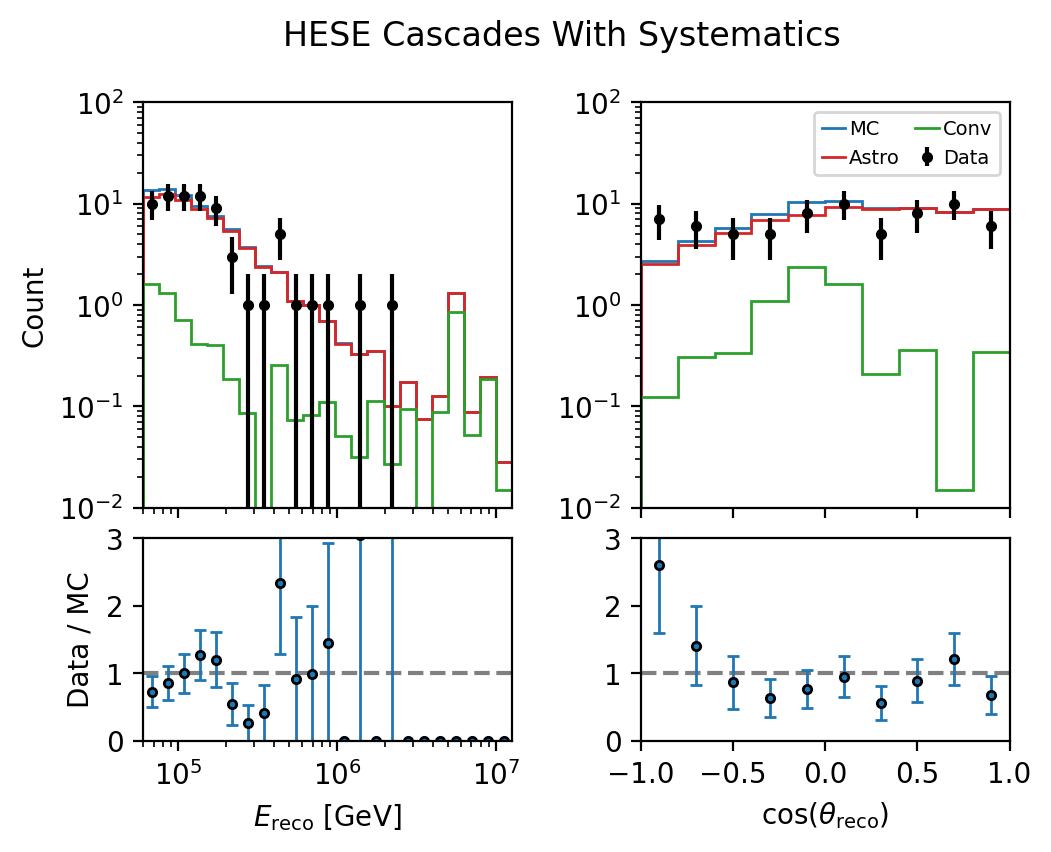

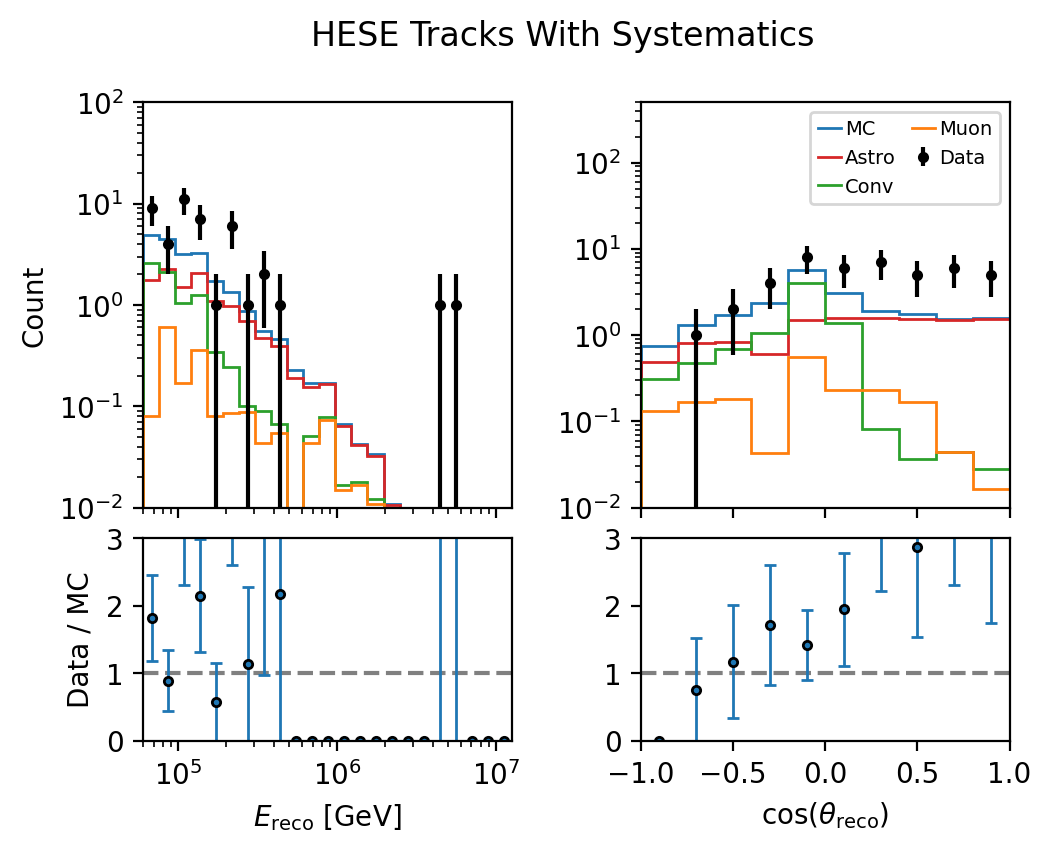

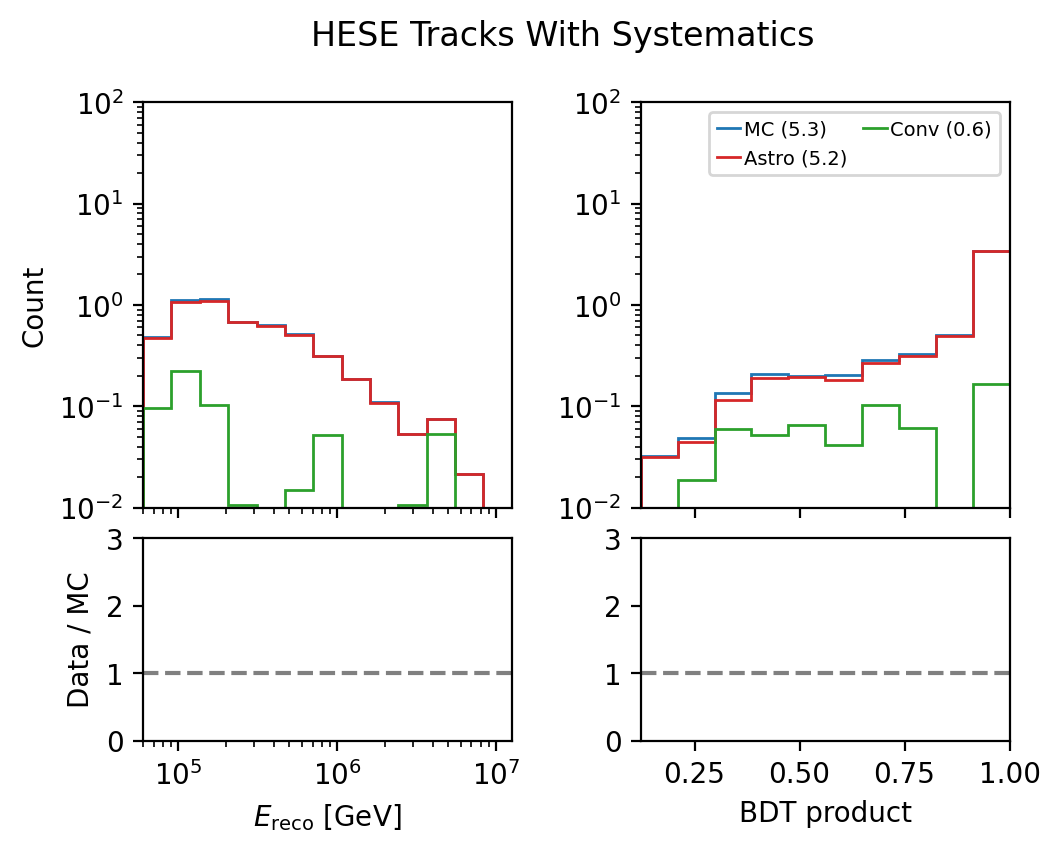

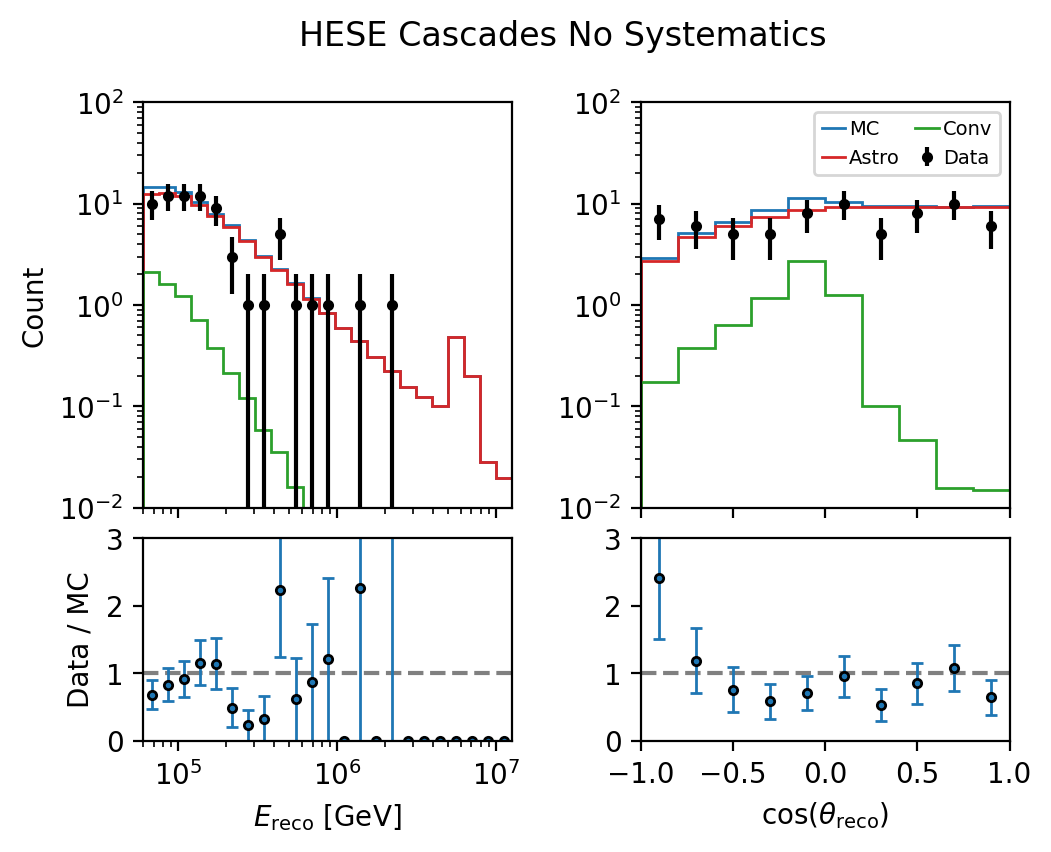

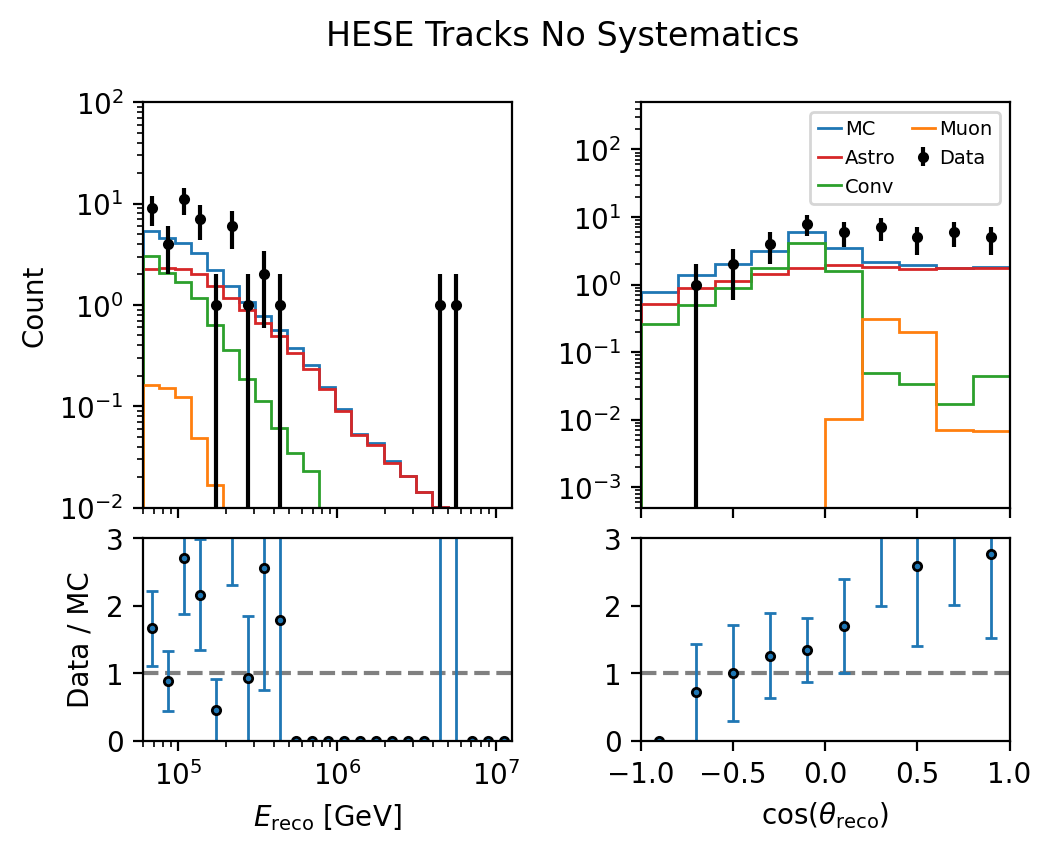

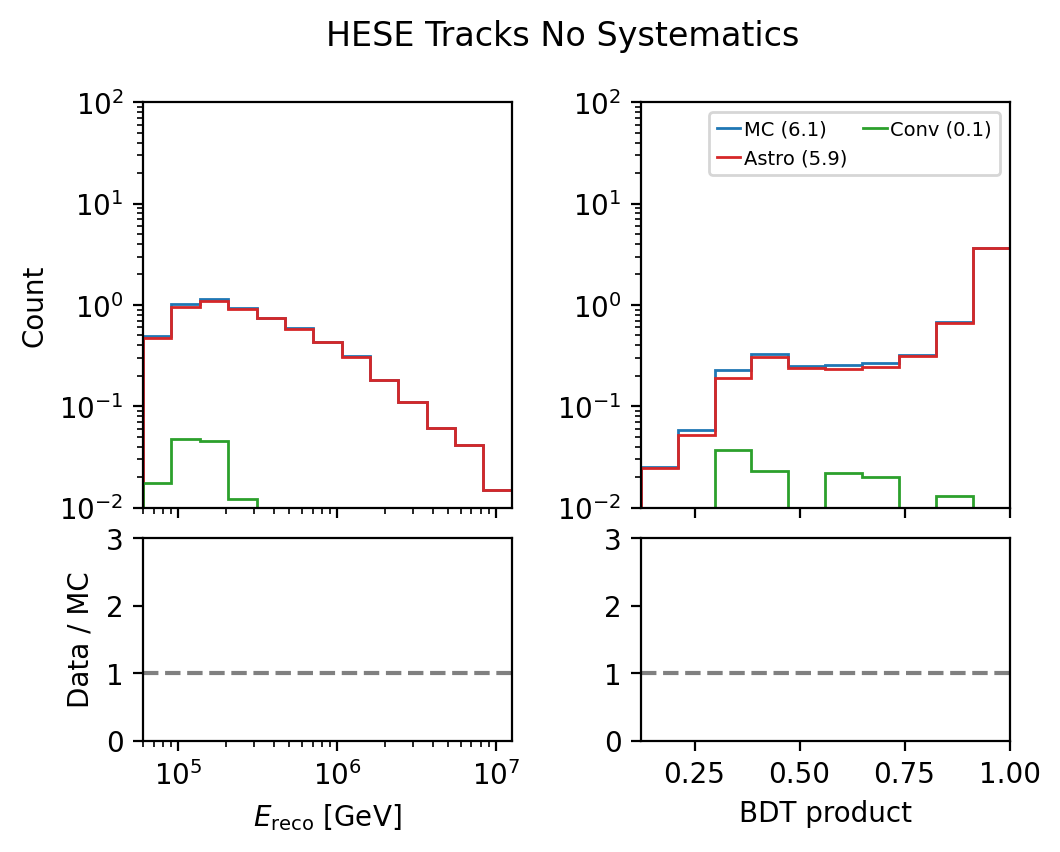

In [25]:
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
COMPONENT_COLORS = {"Astro": "tab:red", "Conv": "tab:green", "Muon": "tab:orange"}

for plot in PLOTS:
    det_config      = plot["det_config"]
    scans           = plot["scans"]
    plot_data     = plot.get("plot_data", True)
    show_counts     = plot.get("show_counts", False)
    plot_components = plot.get("plot_components", False)

    binning = plot["binning"]
    dims    = plot["dim_info"]

    fig, axes = RatioPlot(pad=0.1, vert_pad=0.35).create(ncols=2, dpi=200)

    if plot_data:
        n_data = int(np.sum(histogram_collection[scans[0][0]]["data"]["histograms"][det_config]))
        data_label = f"Data ({n_data})" if show_counts else "Data"
        plot_data_points(
            axes, det_config, histogram_collection, scans[0][0],
            binning=binning, dims=dims, color="black", label=data_label,
        )

    for i, (scan_name, label) in enumerate(scans):
        n_mc = np.sum(histogram_collection[scan_name]["mc"]["histograms"][det_config])
        mc_label = f"{label} ({n_mc:.1f})" if show_counts else label
        plot_mc_and_ratio(
            axes, det_config, histogram_collection, scan_name,
            binning=binning, dims=dims, color=color_cycle[i],
            plot_data=plot_data,
            hist_label=mc_label, ratio_label=mc_label,
        )

        if plot_components:
            for component, comp_color in COMPONENT_COLORS.items():
                if component not in histogram_collection[scan_name]:
                    continue
                if component == "Muon" and ("Double" in det_config or "Cascade" in det_config):
                    continue
                # we only have a muontemplate for reco energy/zenith binning
                if component == "Muon" and "Combined" in det_config and ("reco_energy" not in binning or "reco_zenith" not in binning):
                    continue
                n_comp = np.sum(histogram_collection[scan_name][component]["histograms"][det_config])
                comp_label = f"{component} ({n_comp:.1f})" if show_counts else component
                for col, dim in enumerate(dims):
                    plot_histogram(
                        axes[0][col], histogram_collection[scan_name][component],
                        det_config, dim, binning, dims,
                        draw_style="stairs", label=comp_label, color=comp_color,
                    )

    axes[0][col].legend(loc="upper right", fontsize=7, ncol=2,
                      handlelength=1.2, handletextpad=0.2, columnspacing=0.8)

    for col, dim in enumerate(dims):
        dim_info = dims[dim]
        bins     = binning[dim]

        if dim_info["log_x"]:
            axes[0][col].set_xscale("log")
            axes[1][col].set_xscale("log")
        if dim_info["log_y"]:
            axes[0][col].set_yscale("log")

        axes[0][col].set_xlim(bins.min(), bins.max())
        axes[1][col].set_xlim(bins.min(), bins.max())
        axes[1][col].set_ylim(0.0, 3.0)
        axes[1][col].set_xlabel(dim_info["x_label"])
        axes[1][col].axhline(1, color="grey", linestyle="--", zorder=-10)

        ylim = dim_info.get("ylim", None)
        if ylim is not None:
            axes[0][col].set_ylim(ylim)

    axes[0][0].set_ylabel("Count")
    axes[1][0].set_ylabel("Data / MC")

    fig.suptitle(plot["title"])

    subfolder = os.path.join(save_path, scans[0][0])
    os.makedirs(subfolder, exist_ok=True)
    plt.savefig(os.path.join(subfolder, f"{det_config}.png"), bbox_inches="tight")
    plt.show()
